## Clone the Repository

In [ ]:
#!git clone https://github.com/sovit-123/fastercnn-pytorch-training-pipeline.git

In [ ]:
!git clone https://github.com/sovit-123/vision_transformers

fatal: destination path 'vision_transformers' already exists and is not an empty directory.


In [1]:
from google.colab import drive

drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [2]:
# Enter the repo directory.
%cd /content/gdrive/MyDrive/test_faster_rcnn_nthudd

/content/gdrive/MyDrive/test_faster_rcnn_nthudd


In [3]:
# Install the Requirements
!pip install -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 776.3/776.3 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 33.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 952.4/952.4 kB 61.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 66.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 119.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 868.8/868.8 kB 52.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 81.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 303.6/303.6 kB 31.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.4/123.4 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.7/62.7 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.5/93.5 kB 11.1 MB/s eta 0:00:00
  Attempting uninstall: torch
    Found existin

In [ ]:
#!pip install transformers

In [4]:
!unzip "/content/gdrive/MyDrive/test_faster_rcnn_nthudd/data/updated_nthuddd.v1i.voc.zip" -d "/content/gdrive/MyDrive/test_faster_rcnn_nthudd/data"

Archive:  /content/gdrive/MyDrive/test_faster_rcnn_nthudd/data/updated_nthuddd.v1i.voc.zip
replace /content/gdrive/MyDrive/test_faster_rcnn_nthudd/data/README.dataset.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: /content/gdrive/MyDrive/test_faster_rcnn_nthudd/data/README.dataset.txt  
  inflating: /content/gdrive/MyDrive/test_faster_rcnn_nthudd/data/README.roboflow.txt  
   creating: /content/gdrive/MyDrive/test_faster_rcnn_nthudd/data/test/
 extracting: /content/gdrive/MyDrive/test_faster_rcnn_nthudd/data/test/1011_jpg.rf.b71b98b6824827b839259cdd03c8cc01.jpg  
  inflating: /content/gdrive/MyDrive/test_faster_rcnn_nthudd/data/test/1011_jpg.rf.b71b98b6824827b839259cdd03c8cc01.xml  
 extracting: /content/gdrive/MyDrive/test_faster_rcnn_nthudd/data/test/1027_jpg.rf.9e0a1d8d1bc4d14c83693ad6a005c074.jpg  
  inflating: /content/gdrive/MyDrive/test_faster_rcnn_nthudd/data/test/1027_jpg.rf.9e0a1d8d1bc4d14c83693ad6a005c074.xml  
 extracting: /content/gdrive/MyDrive/test_faster_rcnn

## Download the Dataset

Here we are using the [Aquarium Dataset](https://public.roboflow.com/object-detection/aquarium) from Roboflow.

Download the unzip the dataset to `custom_data` directory.

In [ ]:
#!curl -L "https://public.roboflow.com/ds/CNyGy97q45?key=eSpwiC1Ah7" > roboflow.zip; unzip roboflow.zip -d custom_data; rm roboflow.zip

## Create the Custom Dataset YAML File.

In [5]:
%%writefile data_configs/custom_data.yaml
# Images and labels direcotry should be relative to train.py
TRAIN_DIR_IMAGES: '/content/gdrive/MyDrive/test_faster_rcnn_nthudd/data/train'
TRAIN_DIR_LABELS: '/content/gdrive/MyDrive/test_faster_rcnn_nthudd/data/train'
VALID_DIR_IMAGES: '/content/gdrive/MyDrive/test_faster_rcnn_nthudd/data/valid'
VALID_DIR_LABELS: '/content/gdrive/MyDrive/test_faster_rcnn_nthudd/data/valid'
TEST_DIR_IMAGES: '/content/gdrive/MyDrive/test_faster_rcnn_nthudd/data/test'
TEST_DIR_LABELS: '/content/gdrive/MyDrive/test_faster_rcnn_nthudd/data/test'

# Class names.
CLASSES: [
    '__background__',
    '0', '1'
]

# Number of classes (object classes + 1 for background class in Faster RCNN).
NC: 3

# Whether to save the predictions of the validation set while training.
SAVE_VALID_PREDICTION_IMAGES: True

Overwriting data_configs/custom_data.yaml


In [ ]:
#!pip install vision_transformers

In [ ]:
#!pip install wandb

## Training

In [6]:
!wandb disabled
!python train.py --data data_configs/custom_data.yaml -e 50 -m fasterrcnn_resnet50_fpn -n custom_training -b 8
#!python train.py --data data_configs/custom_data.yaml -e 1 -m fasterrcnn_resnet50_fpn -n custom_training

W&B disabled.
Please intall Vision Transformers to use MobileViT backbones
You can do pip install vision_transformers
Or visit the following link for the latest updates
https://github.com/sovit-123/vision_transformers
Not using distributed mode
device cuda
2024-07-25 20:22:09.517377: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-07-25 20:22:09.517420: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-07-25 20:22:09.518715: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-07-25 20:22:09.525874: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is o

In [ ]:
                #!pip install vision_transformers

## Visualize Validation Results

In [7]:
import matplotlib.pyplot as plt
import glob as glob

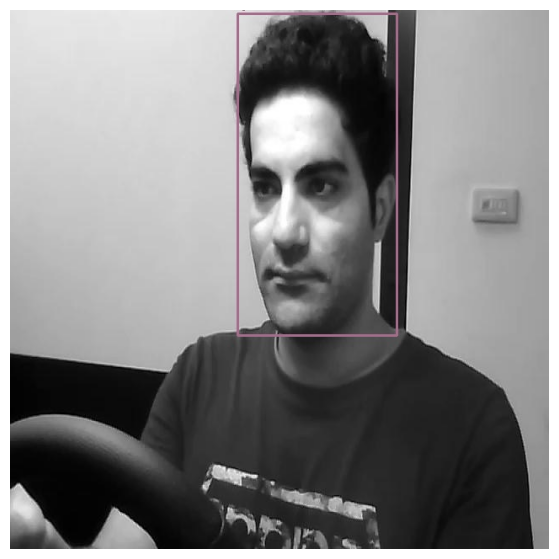

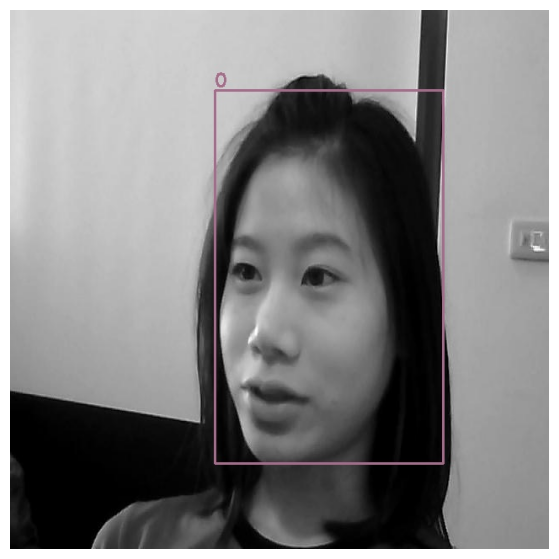

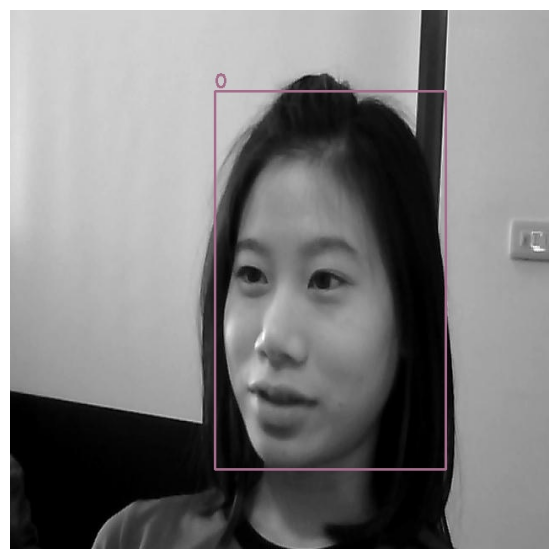

In [8]:
results_dir_path = '/content/gdrive/MyDrive/test_faster_rcnn_nthudd/outputs/training/custom_training'
valid_images = glob.glob(f"{results_dir_path}/*.jpg")

for i in range(3):
    plt.figure(figsize=(10, 7))
    image = plt.imread(valid_images[i])
    plt.imshow(image)
    plt.axis('off')
    plt.show()

In [10]:
!python eval.py --model fasterrcnn_resnet50_fpn --weights outputs/training/custom_training/best_model.pth --data data_configs/custom_data.yaml --batch 4 --verbose

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and will be removed in 0.15, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and will be removed in 0.15. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100% 54/54 [00:19<00:00,  2.74it/s]


{'classes': tensor([1, 2], dtype=torch.int32),
 'map': tensor(0.6343),
 'map_50': tensor(0.8251),
 'map_75': tensor(0.7814),
 'map_large': tensor(0.6395),
 'map_medium': tensor(-1.),
 'map_per_class': tensor([0.6533, 0.6154]),
 'map_small': tensor(-1.),
 'mar_1': tensor(0.7686),
 'mar_10': tensor(0.7772),
 'mar_100': tensor

In [11]:
!python inference.py --weights outputs/training/custom_training/best_model.pth --input data/test/

Building from model name arguments...
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and will be removed in 0.15, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and will be removed in 0.15. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Test instances: 216
Image 1 done...
--------------------------------------------------
Image 2 done...
--------------------------------------------------
Image 3 done...
--------------------------------------------------
Image 4 done...
--------------------------------------------------
Image 5 done...
---------------------

In [9]:
!pip install vision_transformers

  Preparing metadata (setup.py) ... done
  Created wheel for vision_transformers: filename=vision_transformers-0.1.1.0-py3-none-any.whl size=48436 sha256=ad42e24d6b3fbb7c0fc6b5e4221c8c74bb7efc5cd1fc80d5dd64d6b2dc8e5986
  Stored in directory: /root/.cache/pip/wheels/02/f4/94/0a5c8d2a4fcb6aa4c590906ffd3d52dc8edbe94262ecaa7dae
Successfully built vision_transformers
